# Problem 5:

Part 1:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Classifier probability outputs and true labels from Figure 1
threshold = 0.7

c1_probs = [0.15, 0.20, 0.25, 0.37, 0.41, 0.55, 0.65, 0.80, 0.92, 0.99]
c2_probs = [0.33, 0.22, 0.10, 0.41, 0.68, 0.59, 0.72, 0.75, 0.64, 0.95]
y_true   = [  0,    0,    1,    0,    1,    0,    0,    1,    1,    1  ]  # 0=negative, 1=positive

# Predict positive (1) if P(y=+|Ci) >= threshold
c1_pred = [1 if p >= threshold else 0 for p in c1_probs]
c2_pred = [1 if p >= threshold else 0 for p in c2_probs]

print('C1 predictions:', c1_pred)
print('C2 predictions:', c2_pred)
print('True labels:   ', y_true)

C1 predictions: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
C2 predictions: [0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
True labels:    [0, 0, 1, 0, 1, 0, 0, 1, 1, 1]


In [3]:
def confusion_matrix_manual(y_true, y_pred):
    """Return [[TN, FP], [FN, TP]] for binary labels (0=neg, 1=pos)."""
    TP = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))
    TN = sum(t == 0 and p == 0 for t, p in zip(y_true, y_pred))
    FP = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))
    FN = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))
    return np.array([[TN, FP], [FN, TP]])

cm1 = confusion_matrix_manual(y_true, c1_pred)
cm2 = confusion_matrix_manual(y_true, c2_pred)

for name, cm in [('C1', cm1), ('C2', cm2)]:
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    print(f'{name}: TP={TP}, FP={FP}, FN={FN}, TN={TN}')

C1: TP=3, FP=0, FN=2, TN=5
C2: TP=2, FP=1, FN=3, TN=4


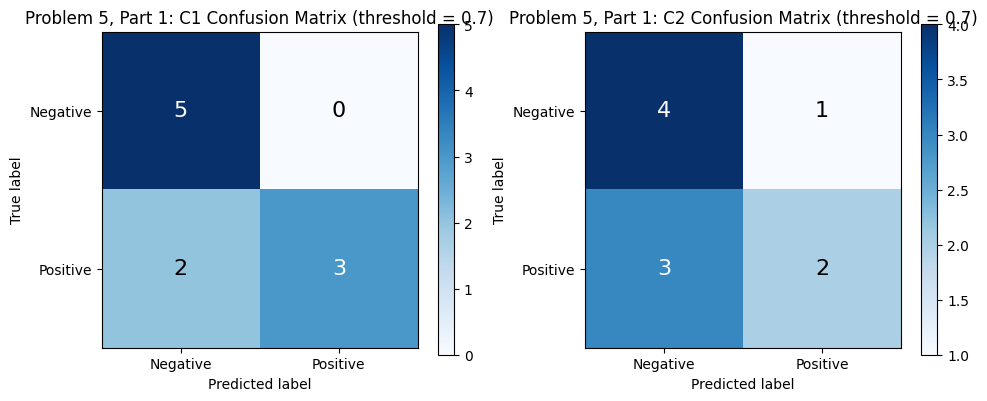

In [4]:
labels = ['Negative', 'Positive']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cm, name in zip(axes, [cm1, cm2], ['C1', 'C2']):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    # Annotate each cell with its count
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center', fontsize=16,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(f'Problem 5, Part 1: {name} Confusion Matrix (threshold = {threshold})')

plt.tight_layout()
plt.show()

**C1 (threshold = 0.7):** TP = 3, FP = 0, FN = 2, TN = 5. C1 predicts positive only for samples 8, 9, and 10 (probabilities 0.80, 0.92, 0.99). It has **perfect precision** — every positive prediction is correct — but misses two true positives (samples 3 and 5), resulting in two false negatives.

**C2 (threshold = 0.7):** TP = 2, FP = 1, FN = 3, TN = 4. C2 predicts positive for samples 7, 8, and 10 (probabilities 0.72, 0.75, 0.95). Sample 7 is actually negative, yielding one false positive. C2 also misses three true positives (samples 3, 5, and 9), giving it lower recall than C1.

Part 2:

In [5]:
# ROC coordinates: (FPR, TPR)
# FPR = FP / (FP + TN),  TPR = TP / (TP + FN)

for name, cm in [('C1', cm1), ('C2', cm2)]:
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    print(f'{name}:')
    print(f'  TPR = TP/(TP+FN) = {TP}/({TP}+{FN}) = {TPR:.4f}')
    print(f'  FPR = FP/(FP+TN) = {FP}/({FP}+{TN}) = {FPR:.4f}')
    print(f'  ROC point (FPR, TPR) = ({FPR:.4f}, {TPR:.4f})')
    print()


C1:
  TPR = TP/(TP+FN) = 3/(3+2) = 0.6000
  FPR = FP/(FP+TN) = 0/(0+5) = 0.0000
  ROC point (FPR, TPR) = (0.0000, 0.6000)

C2:
  TPR = TP/(TP+FN) = 2/(2+3) = 0.4000
  FPR = FP/(FP+TN) = 1/(1+4) = 0.2000
  ROC point (FPR, TPR) = (0.2000, 0.4000)



Using the confusion matrices from Part 1 and the formulas:

$$\mathrm{TPR} = \frac{TP}{TP+FN}, \qquad \mathrm{FPR} = \frac{FP}{FP+TN}$$

**C1:** $\mathrm{TPR} = \frac{3}{3+2} = 0.6$, $\quad \mathrm{FPR} = \frac{0}{0+5} = 0.0$ $\;\Rightarrow\;$ ROC point $= (0.0,\ 0.6)$

**C2:** $\mathrm{TPR} = \frac{2}{2+3} = 0.4$, $\quad \mathrm{FPR} = \frac{1}{1+4} = 0.2$ $\;\Rightarrow\;$ ROC point $= (0.2,\ 0.4)$

C1 lies closer to the top-left corner of the ROC space, indicating better overall discrimination at this threshold.

Part 3:

In [6]:
# PR coordinates: (Recall, Precision)
# Recall    = TP / (TP + FN)
# Precision = TP / (TP + FP)

for name, cm in [('C1', cm1), ('C2', cm2)]:
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    recall    = TP / (TP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
    print(f'{name}:')
    print(f'  Recall    = TP/(TP+FN) = {TP}/({TP}+{FN}) = {recall:.4f}')
    print(f'  Precision = TP/(TP+FP) = {TP}/({TP}+{FP}) = {precision:.4f}')
    print(f'  PR point (Recall, Precision) = ({recall:.4f}, {precision:.4f})')
    print()


C1:
  Recall    = TP/(TP+FN) = 3/(3+2) = 0.6000
  Precision = TP/(TP+FP) = 3/(3+0) = 1.0000
  PR point (Recall, Precision) = (0.6000, 1.0000)

C2:
  Recall    = TP/(TP+FN) = 2/(2+3) = 0.4000
  Precision = TP/(TP+FP) = 2/(2+1) = 0.6667
  PR point (Recall, Precision) = (0.4000, 0.6667)



Using the confusion matrices from Part 1 and the formulas:

$$\mathrm{Recall} = \frac{TP}{TP+FN}, \qquad \mathrm{Precision} = \frac{TP}{TP+FP}$$

**C1:** $\mathrm{Recall} = \frac{3}{3+2} = 0.6$, $\quad \mathrm{Precision} = \frac{3}{3+0} = 1.0$ $\;\Rightarrow\;$ PR point $= (0.6,\ 1.0)$

**C2:** $\mathrm{Recall} = \frac{2}{2+3} = 0.4$, $\quad \mathrm{Precision} = \frac{2}{2+1} \approx 0.667$ $\;\Rightarrow\;$ PR point $= (0.4,\ 0.667)$

C1 achieves perfect precision (no false positives) at the cost of lower recall, placing it at the top of the PR space. C2 has lower precision due to its one false positive, and also lower recall.